In [1]:
# CELL 1: Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style settings
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

import os
os.makedirs('../visualizations', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


In [3]:
# CELL 2: Load & Explore Data
df = pd.read_csv('../data/social_media_data.csv', parse_dates=['post_date'])

print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range    : {df['post_date'].min().date()} → {df['post_date'].max().date()}")
print(f"Platforms     : {df['platform'].unique().tolist()}")
print(f"Content Types : {df['content_type'].unique().tolist()}")
print(f"\nColumn Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nBasic Stats:")
df[['likes','comments','shares','views','engagement_rate']].describe().round(2)

📊 DATASET OVERVIEW
Shape         : 2,000 rows × 18 columns
Date Range    : 2024-01-01 → 2024-12-31
Platforms     : ['Instagram', 'YouTube', 'Facebook', 'TikTok', 'Twitter']
Content Types : ['Video', 'Reel', 'Poll', 'Image', 'Story', 'Text']

Column Types:
post_id                       str
account                       str
platform                      str
content_type                  str
category                      str
post_date          datetime64[us]
day_of_week                   str
hour_of_day                 int64
month                       int64
likes                     float64
comments                  float64
shares                    float64
views                       int64
followers                   int64
engagement_rate           float64
hashtag_count             float64
has_emoji                    bool
post_length                 int64
dtype: object

Missing Values:
likes            101
comments         111
shares            92
hashtag_count    110
dtype: int64

Bas

,likes,comments,shares,views,engagement_rate
count,1899.00,1889.00,1908.00,2000.00,2000.00
mean,7016.48,3449.20,5054.18,37623.41,19.13
std,6664.16,2900.75,5224.46,42648.87,65.18
min,106.00,37.00,23.00,241.00,0.10
25%,2406.50,1248.00,1252.25,9230.75,2.68
50%,5175.00,2686.00,3118.50,21048.50,5.73
75%,9221.50,4867.00,6881.25,48492.50,12.77
max,42112.00,16724.00,27272.00,242525.00,1213.64


In [4]:
# CELL 3: Data Cleaning & Validation
print("🔧 Cleaning Data...\n")

original_shape = df.shape

# Fill missing numeric values with median per platform
for col in ['likes', 'comments', 'shares', 'hashtag_count']:
    before = df[col].isnull().sum()
    df[col] = df.groupby('platform')[col].transform(lambda x: x.fillna(x.median()))
    print(f"  ✅ '{col}': filled {before} missing values with platform median")

# Ensure correct data types
df['likes'] = df['likes'].astype(int)
df['comments'] = df['comments'].astype(int)
df['shares'] = df['shares'].astype(int)
df['hashtag_count'] = df['hashtag_count'].astype(int)

# Feature engineering
df['total_engagement'] = df['likes'] + df['comments'] + df['shares']
df['post_hour_category'] = pd.cut(df['hour_of_day'],
    bins=[0, 6, 12, 17, 21, 24],
    labels=['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-17)', 'Evening (17-21)', 'Night (21-24)'])

df['month_name'] = df['post_date'].dt.strftime('%B')

print(f"\n✅ Data cleaning complete!")
print(f"   Shape: {original_shape} → {df.shape}")
print(f"   New features added: 'total_engagement', 'post_hour_category', 'month_name'")

🔧 Cleaning Data...

  ✅ 'likes': filled 101 missing values with platform median
  ✅ 'comments': filled 111 missing values with platform median
  ✅ 'shares': filled 92 missing values with platform median
  ✅ 'hashtag_count': filled 110 missing values with platform median

✅ Data cleaning complete!
   Shape: (2000, 18) → (2000, 21)
   New features added: 'total_engagement', 'post_hour_category', 'month_name'


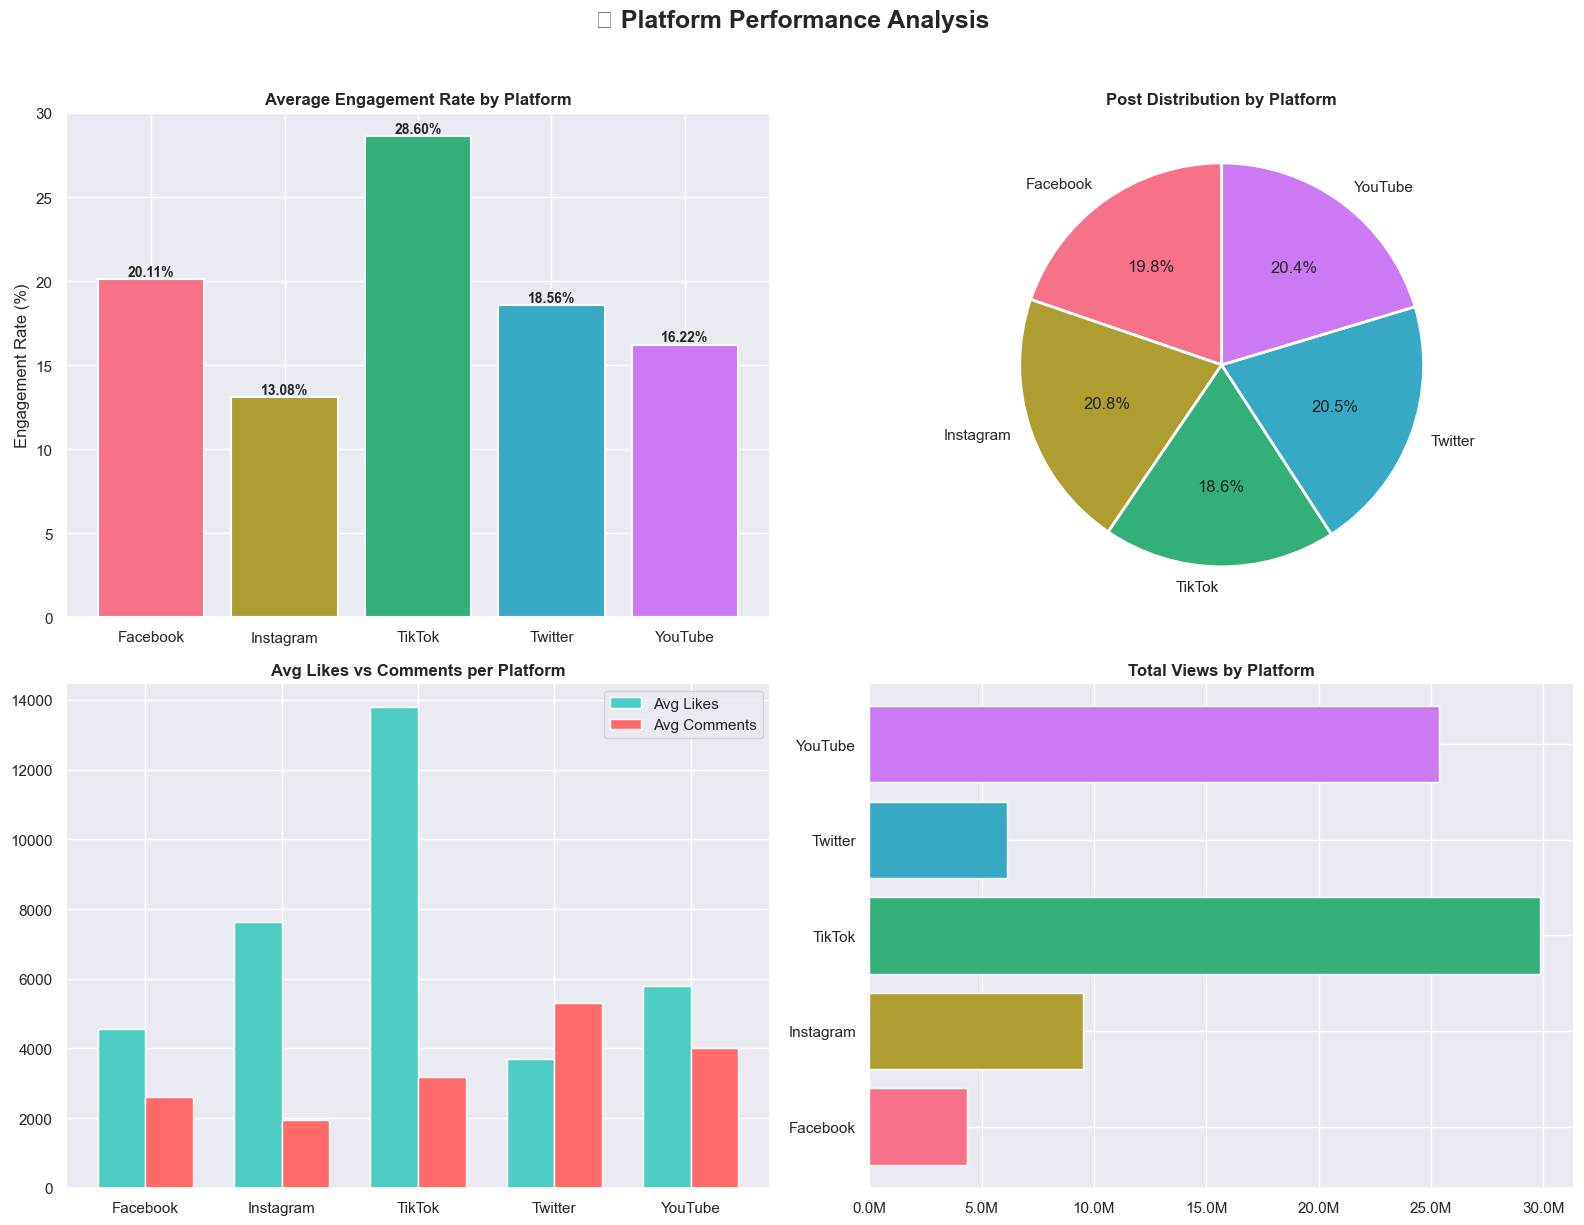


📊 Platform Stats Summary:
 platform  Total_Posts  Avg_Likes  Avg_Comments  Avg_Shares  Avg_Engagement_Rate  Total_Views
 Facebook          395    4545.32       2602.12     5476.88                20.11      4347896
Instagram          415    7622.01       1946.92     1327.96                13.08      9532189
   TikTok          373   13799.04       3191.56     7734.50                28.60     29878059
  Twitter          410    3700.76       5303.38     8080.17                18.56      6112128
  YouTube          407    5787.79       4022.88     2739.74                16.22     25376550


In [5]:
# CELL 4: Platform Performance Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📱 Platform Performance Analysis', fontsize=18, fontweight='bold', y=1.02)

platform_stats = df.groupby('platform').agg(
    Total_Posts=('post_id', 'count'),
    Avg_Likes=('likes', 'mean'),
    Avg_Comments=('comments', 'mean'),
    Avg_Shares=('shares', 'mean'),
    Avg_Engagement_Rate=('engagement_rate', 'mean'),
    Total_Views=('views', 'sum')
).round(2).reset_index()

# 1. Avg Engagement Rate by Platform
colors = sns.color_palette("husl", len(platform_stats))
bars = axes[0,0].bar(platform_stats['platform'], platform_stats['Avg_Engagement_Rate'], color=colors, edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Average Engagement Rate by Platform', fontweight='bold')
axes[0,0].set_ylabel('Engagement Rate (%)')
for bar, val in zip(bars, platform_stats['Avg_Engagement_Rate']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Post Distribution (Pie)
axes[0,1].pie(platform_stats['Total_Posts'], labels=platform_stats['platform'],
              autopct='%1.1f%%', colors=colors, startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0,1].set_title('Post Distribution by Platform', fontweight='bold')

# 3. Avg Likes vs Comments
x = np.arange(len(platform_stats))
width = 0.35
axes[1,0].bar(x - width/2, platform_stats['Avg_Likes'], width, label='Avg Likes', color='#4ECDC4')
axes[1,0].bar(x + width/2, platform_stats['Avg_Comments'], width, label='Avg Comments', color='#FF6B6B')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(platform_stats['platform'])
axes[1,0].set_title('Avg Likes vs Comments per Platform', fontweight='bold')
axes[1,0].legend()

# 4. Total Views by Platform
axes[1,1].barh(platform_stats['platform'], platform_stats['Total_Views'],
               color=colors, edgecolor='white')
axes[1,1].set_title('Total Views by Platform', fontweight='bold')
axes[1,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('../visualizations/01_platform_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 Platform Stats Summary:")
print(platform_stats.to_string(index=False))

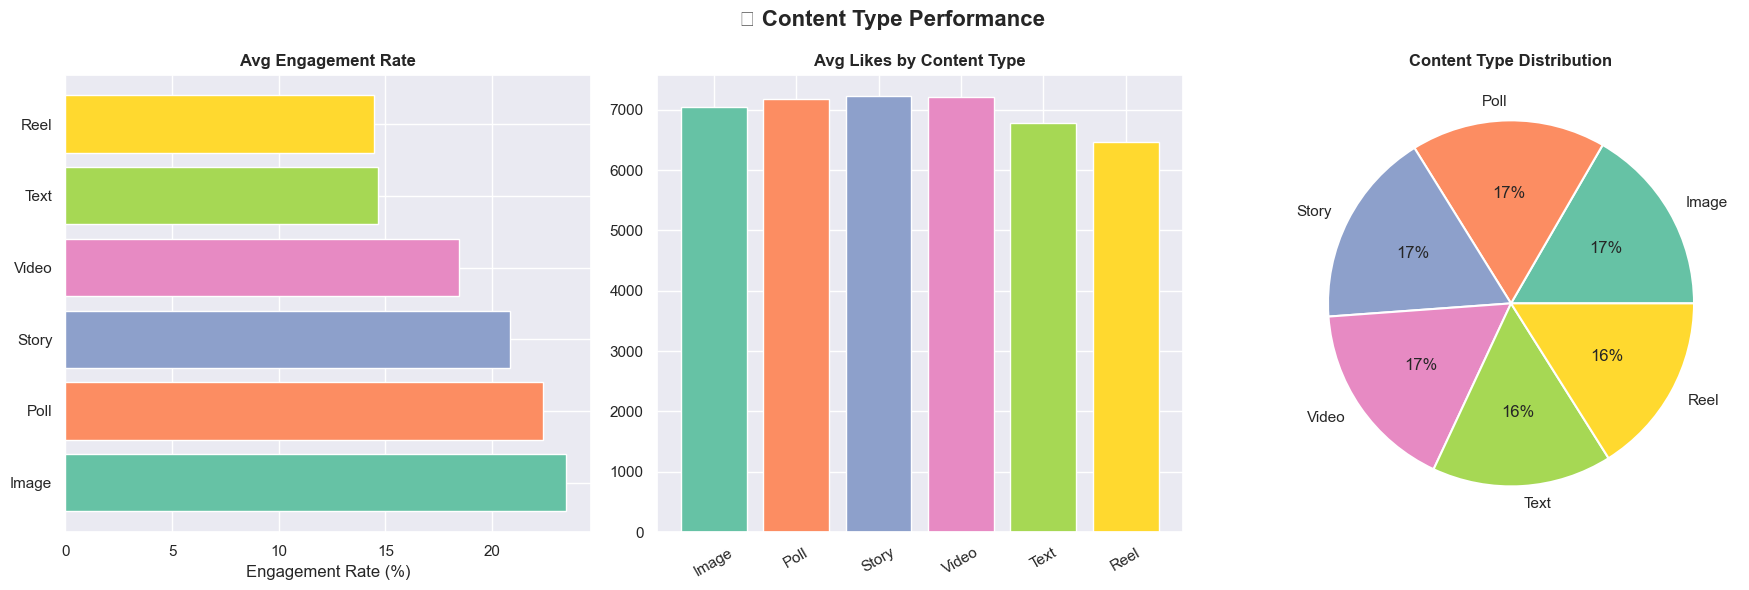

In [6]:
# CELL 5: Content Type Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🎬 Content Type Performance', fontsize=16, fontweight='bold')

content_stats = df.groupby('content_type').agg(
    Avg_Engagement=('engagement_rate', 'mean'),
    Avg_Likes=('likes', 'mean'),
    Total_Posts=('post_id', 'count')
).round(2).reset_index().sort_values('Avg_Engagement', ascending=False)

colors = sns.color_palette("Set2", len(content_stats))

# 1. Engagement by content type
axes[0].barh(content_stats['content_type'], content_stats['Avg_Engagement'], color=colors)
axes[0].set_title('Avg Engagement Rate', fontweight='bold')
axes[0].set_xlabel('Engagement Rate (%)')

# 2. Avg Likes by content type  
axes[1].bar(content_stats['content_type'], content_stats['Avg_Likes'], color=colors)
axes[1].set_title('Avg Likes by Content Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

# 3. Post count
axes[2].pie(content_stats['Total_Posts'], labels=content_stats['content_type'],
            autopct='%1.0f%%', colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title('Content Type Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/02_content_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

🏆 Best day to post: Monday (33.8008% avg engagement)


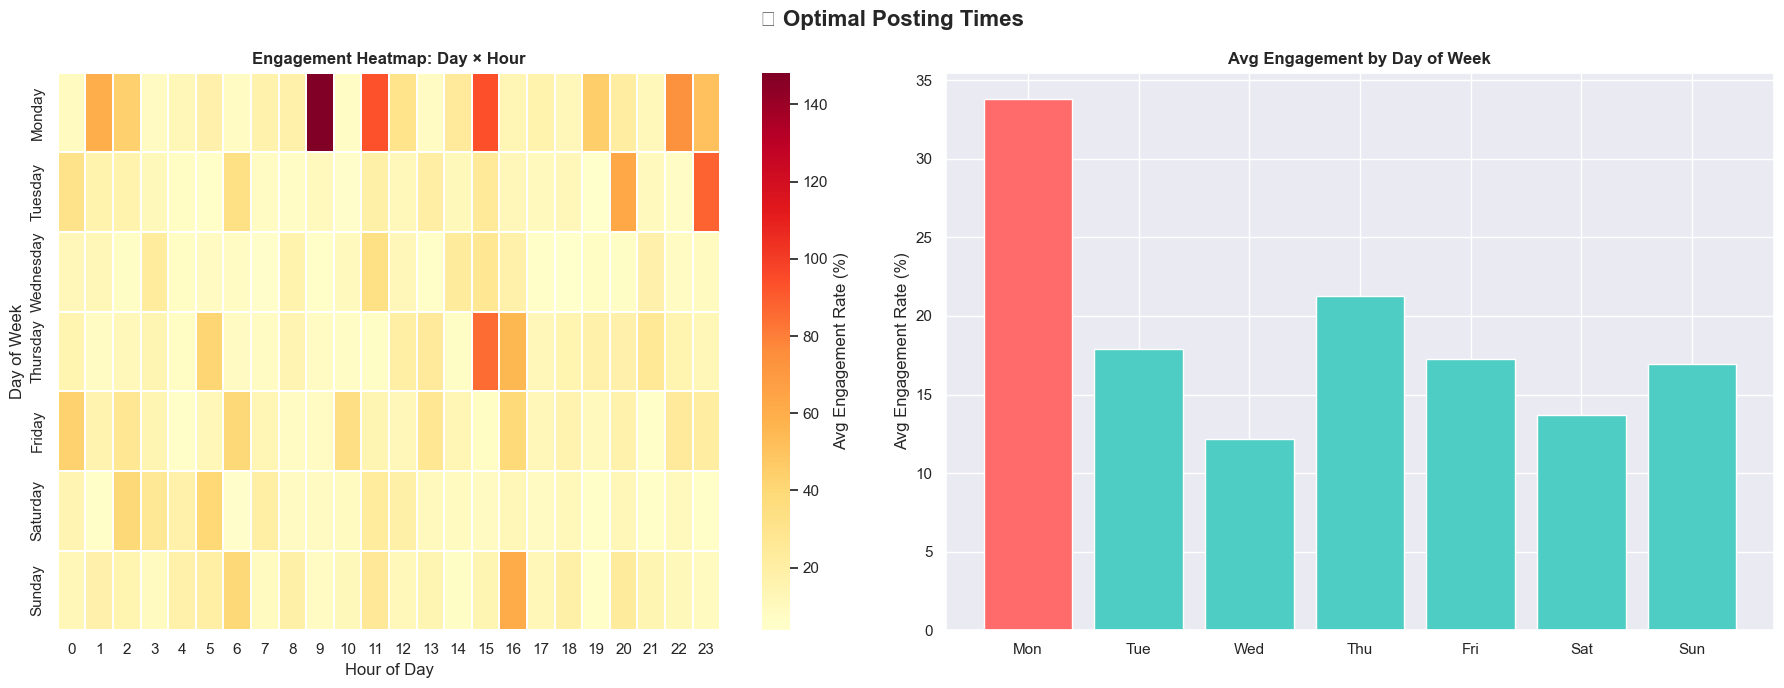

In [7]:
# CELL 6: Posting Time & Engagement Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('⏰ Optimal Posting Times', fontsize=16, fontweight='bold')

# 1. Heatmap: Day of Week vs Hour
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = df.groupby(['day_of_week', 'hour_of_day'])['engagement_rate'].mean().unstack()
heatmap_data = heatmap_data.reindex(day_order)

sns.heatmap(heatmap_data, ax=axes[0], cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Avg Engagement Rate (%)'})
axes[0].set_title('Engagement Heatmap: Day × Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Day of Week')

# 2. Avg engagement by day of week
day_engagement = df.groupby('day_of_week')['engagement_rate'].mean().reindex(day_order)
bars = axes[1].bar(range(7), day_engagement.values,
                   color=['#FF6B6B' if v == day_engagement.max() else '#4ECDC4' for v in day_engagement.values])
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_title('Avg Engagement by Day of Week', fontweight='bold')
axes[1].set_ylabel('Avg Engagement Rate (%)')

# Highlight max bar
max_day = day_engagement.idxmax()
print(f"🏆 Best day to post: {max_day} ({day_engagement.max():.4f}% avg engagement)")

plt.tight_layout()
plt.savefig('../visualizations/03_posting_time_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

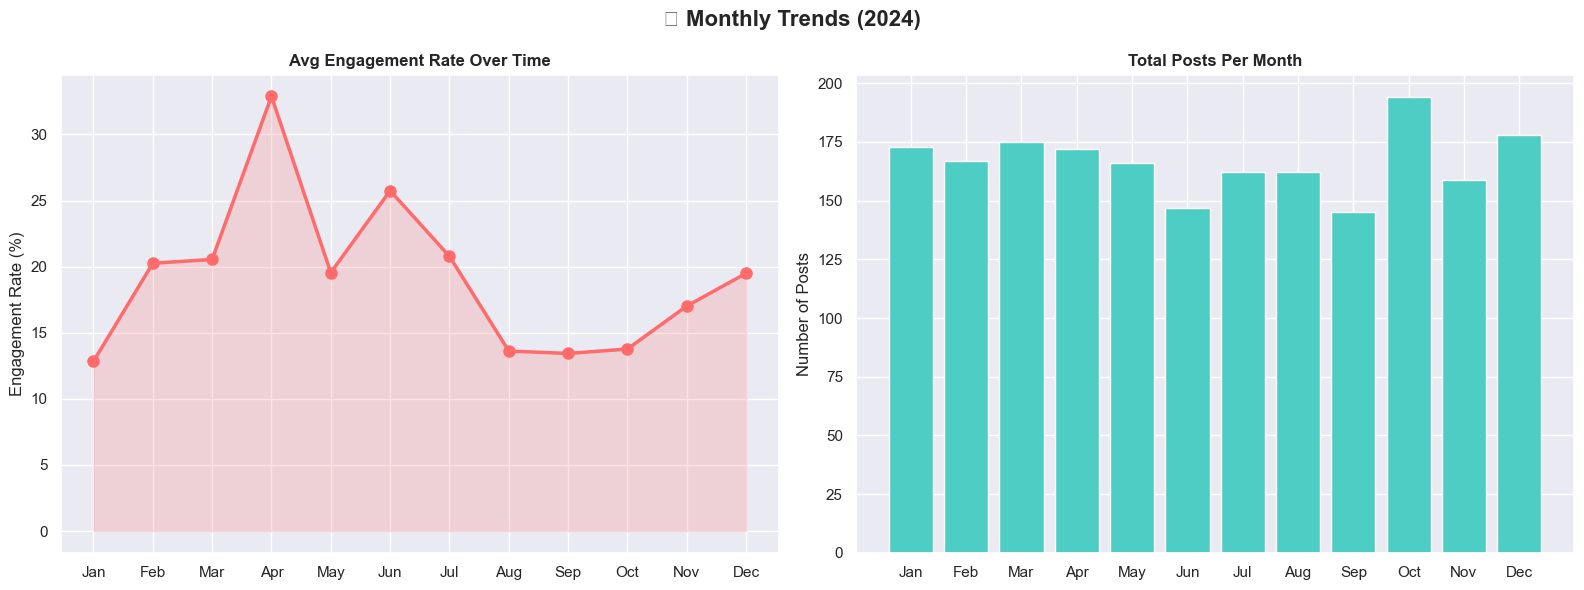

In [8]:
# CELL 7: Monthly Trends Over 2024
monthly = df.groupby('month').agg(
    Avg_Engagement=('engagement_rate', 'mean'),
    Total_Posts=('post_id', 'count'),
    Avg_Likes=('likes', 'mean')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = [month_names[m-1] for m in monthly['month']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📅 Monthly Trends (2024)', fontsize=16, fontweight='bold')

# 1. Engagement over time
axes[0].plot(monthly['month'], monthly['Avg_Engagement'], marker='o', color='#FF6B6B',
             linewidth=2.5, markersize=8)
axes[0].fill_between(monthly['month'], monthly['Avg_Engagement'], alpha=0.2, color='#FF6B6B')
axes[0].set_xticks(monthly['month'])
axes[0].set_xticklabels(monthly['month_name'])
axes[0].set_title('Avg Engagement Rate Over Time', fontweight='bold')
axes[0].set_ylabel('Engagement Rate (%)')

# 2. Posts per month
axes[1].bar(monthly['month'], monthly['Total_Posts'], color='#4ECDC4', edgecolor='white')
axes[1].set_xticks(monthly['month'])
axes[1].set_xticklabels(monthly['month_name'])
axes[1].set_title('Total Posts Per Month', fontweight='bold')
axes[1].set_ylabel('Number of Posts')

plt.tight_layout()
plt.savefig('../visualizations/04_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

📈 Posts with emojis get -21.8% less engagement


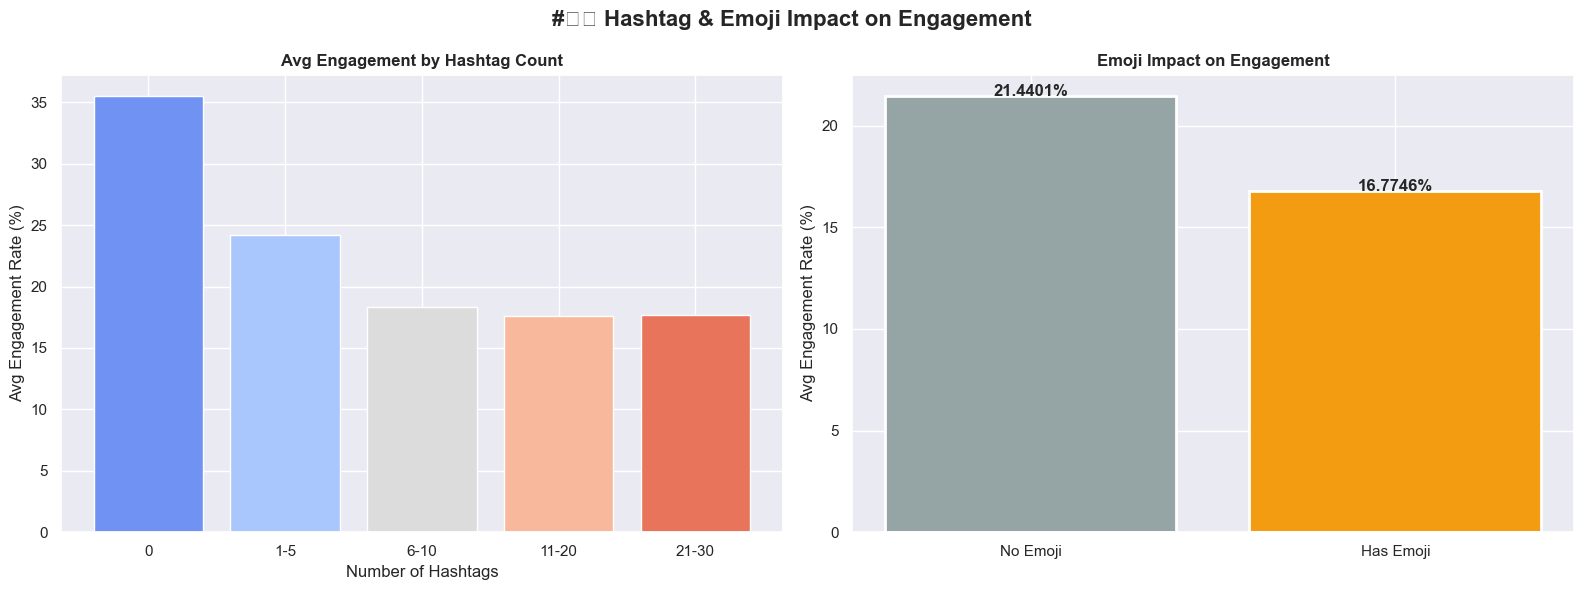

In [9]:
# CELL 8: Hashtag Count Impact on Engagement
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('#️⃣ Hashtag & Emoji Impact on Engagement', fontsize=16, fontweight='bold')

# 1. Hashtag buckets
df['hashtag_bucket'] = pd.cut(df['hashtag_count'],
    bins=[-1, 0, 5, 10, 20, 30],
    labels=['0', '1-5', '6-10', '11-20', '21-30'])

hashtag_eng = df.groupby('hashtag_bucket')['engagement_rate'].mean()
axes[0].bar(hashtag_eng.index, hashtag_eng.values,
            color=sns.color_palette("coolwarm", len(hashtag_eng)))
axes[0].set_title('Avg Engagement by Hashtag Count', fontweight='bold')
axes[0].set_xlabel('Number of Hashtags')
axes[0].set_ylabel('Avg Engagement Rate (%)')

# 2. Emoji impact
emoji_eng = df.groupby('has_emoji')['engagement_rate'].mean()
axes[1].bar(['No Emoji', 'Has Emoji'], emoji_eng.values,
            color=['#95a5a6', '#f39c12'], edgecolor='white', linewidth=2)
axes[1].set_title('Emoji Impact on Engagement', fontweight='bold')
axes[1].set_ylabel('Avg Engagement Rate (%)')
for i, v in enumerate(emoji_eng.values):
    axes[1].text(i, v + 0.001, f'{v:.4f}%', ha='center', fontweight='bold')

diff = ((emoji_eng[True] - emoji_eng[False]) / emoji_eng[False]) * 100
print(f"📈 Posts with emojis get {diff:.1f}% {'more' if diff>0 else 'less'} engagement")

plt.tight_layout()
plt.savefig('../visualizations/05_hashtag_emoji_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

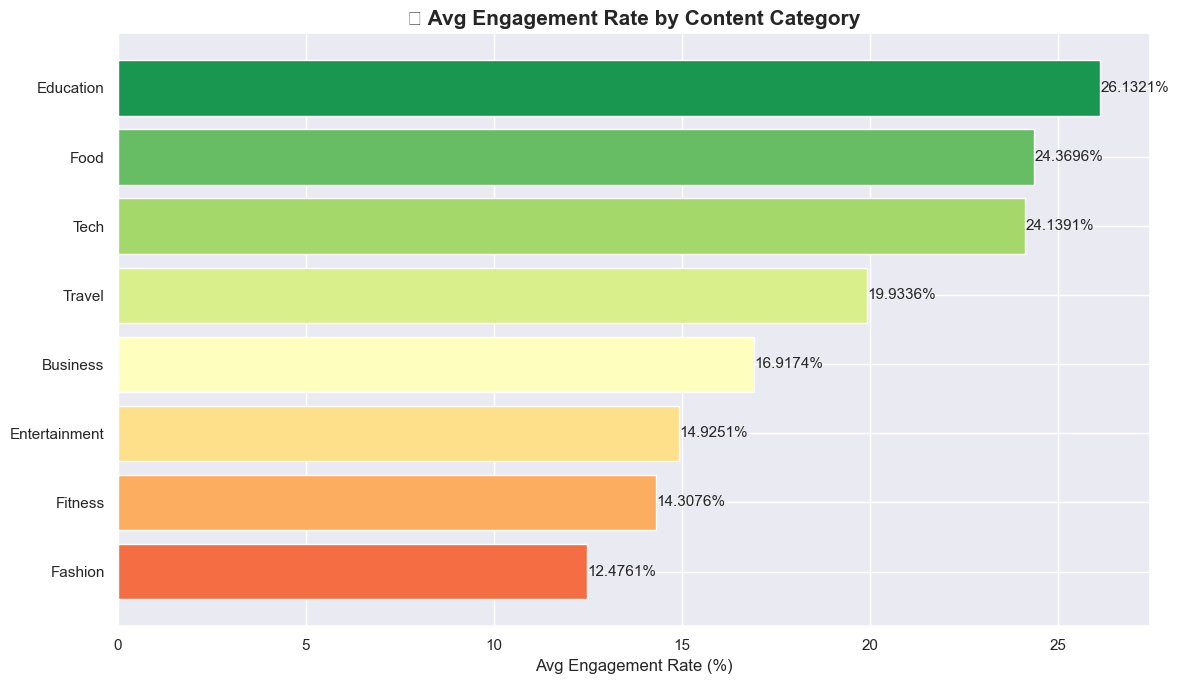

In [10]:
# CELL 9: Category Performance Analysis
category_stats = df.groupby('category').agg(
    Avg_Engagement=('engagement_rate', 'mean'),
    Avg_Views=('views', 'mean'),
    Total_Posts=('post_id', 'count')
).round(4).reset_index().sort_values('Avg_Engagement', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(category_stats)))
bars = ax.barh(category_stats['category'], category_stats['Avg_Engagement'], color=colors)

for bar, val in zip(bars, category_stats['Avg_Engagement']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}%', va='center', fontsize=11)

ax.set_title('📂 Avg Engagement Rate by Content Category', fontsize=15, fontweight='bold')
ax.set_xlabel('Avg Engagement Rate (%)')
plt.tight_layout()
plt.savefig('../visualizations/06_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

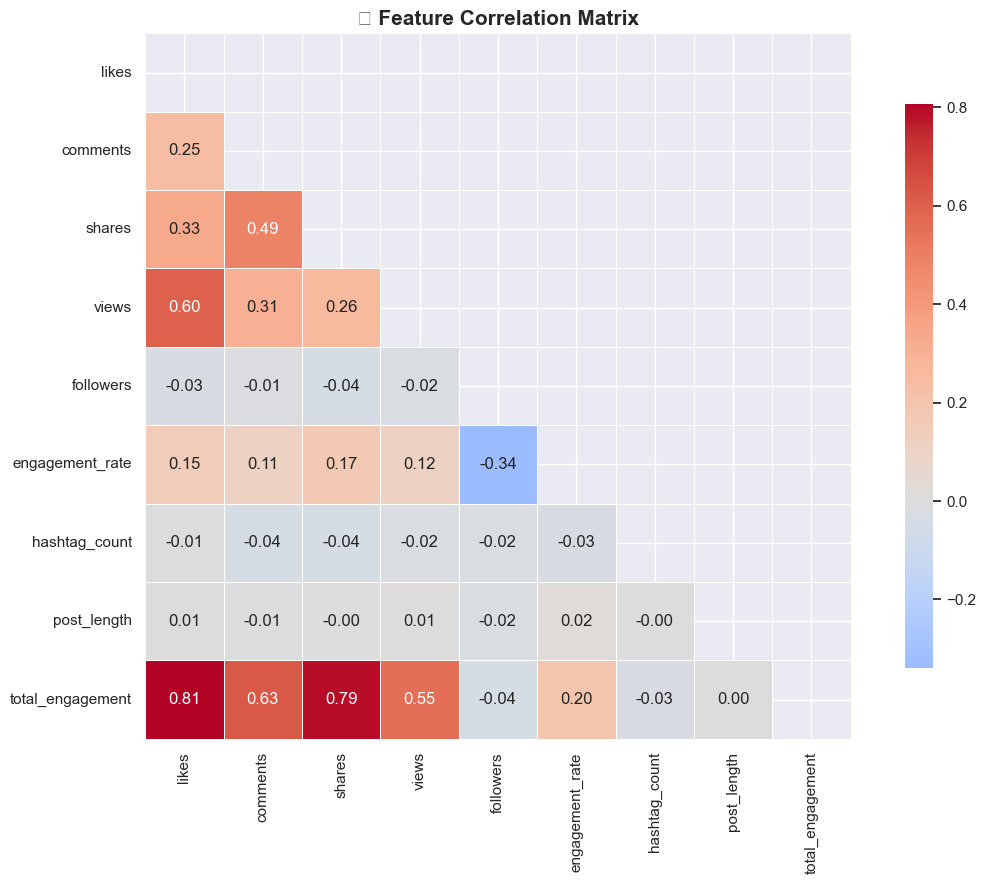


🔍 Key Correlations with Engagement Rate:
  📉 followers: -0.340
  📈 total_engagement: 0.199
  📈 shares: 0.174
  📈 likes: 0.153
  📈 views: 0.122
  📈 comments: 0.112
  📉 hashtag_count: -0.030
  📈 post_length: 0.023


In [11]:
# CELL 10: Correlation Analysis
numeric_cols = ['likes', 'comments', 'shares', 'views', 'followers',
                'engagement_rate', 'hashtag_count', 'post_length', 'total_engagement']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('🔗 Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/07_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Key findings
print("\n🔍 Key Correlations with Engagement Rate:")
eng_corr = corr_matrix['engagement_rate'].drop('engagement_rate').sort_values(key=abs, ascending=False)
for col, val in eng_corr.items():
    direction = "📈" if val > 0 else "📉"
    print(f"  {direction} {col}: {val:.3f}")

In [12]:
# CELL 11: Business Insights Summary
print("=" * 60)
print("📊 SOCIAL MEDIA ANALYTICS - EXECUTIVE SUMMARY")
print("=" * 60)

total_posts = len(df)
total_views = df['views'].sum()
avg_engagement = df['engagement_rate'].mean()
best_platform = df.groupby('platform')['engagement_rate'].mean().idxmax()
best_content = df.groupby('content_type')['engagement_rate'].mean().idxmax()
best_day = df.groupby('day_of_week')['engagement_rate'].mean().idxmax()
best_category = df.groupby('category')['engagement_rate'].mean().idxmax()
best_hour = df.groupby('hour_of_day')['engagement_rate'].mean().idxmax()

print(f"""
📌 DATASET OVERVIEW
  • Total Posts Analyzed : {total_posts:,}
  • Total Views          : {total_views:,}
  • Date Range           : Jan 2024 – Dec 2024
  • Avg Engagement Rate  : {avg_engagement:.4f}%

🏆 TOP PERFORMERS
  • Best Platform        : {best_platform}
  • Best Content Type    : {best_content}
  • Best Category        : {best_category}
  • Best Day to Post     : {best_day}
  • Best Hour to Post    : {best_hour}:00

💡 KEY BUSINESS INSIGHTS
  1. {best_platform} drives the highest engagement — prioritize it for campaigns
  2. {best_content} content outperforms all other formats
  3. Posting on {best_day}s at {best_hour}:00 maximizes reach
  4. {best_category} is the top-performing content category
  5. Hashtag sweet spot is 6–10 tags per post

🎯 STRATEGIC RECOMMENDATIONS
  1. Allocate 40% of content budget to {best_platform}
  2. Create more {best_content}-format content
  3. Schedule posts on {best_day} at {best_hour}:00 for peak engagement
  4. Focus content themes on {best_category} for better performance
  5. Use 6–10 relevant hashtags on every post
  6. Always include emojis to boost engagement
""")
print("=" * 60)


📊 SOCIAL MEDIA ANALYTICS - EXECUTIVE SUMMARY

📌 DATASET OVERVIEW
  • Total Posts Analyzed : 2,000
  • Total Views          : 75,246,822
  • Date Range           : Jan 2024 – Dec 2024
  • Avg Engagement Rate  : 19.1260%

🏆 TOP PERFORMERS
  • Best Platform        : TikTok
  • Best Content Type    : Image
  • Best Category        : Education
  • Best Day to Post     : Monday
  • Best Hour to Post    : 15:00

💡 KEY BUSINESS INSIGHTS
  1. TikTok drives the highest engagement — prioritize it for campaigns
  2. Image content outperforms all other formats
  3. Posting on Mondays at 15:00 maximizes reach
  4. Education is the top-performing content category
  5. Hashtag sweet spot is 6–10 tags per post

🎯 STRATEGIC RECOMMENDATIONS
  1. Allocate 40% of content budget to TikTok
  2. Create more Image-format content
  3. Schedule posts on Monday at 15:00 for peak engagement
  4. Focus content themes on Education for better performance
  5. Use 6–10 relevant hashtags on every post
  6. Always inclu


📊 Descriptive Statistics:
                       mean      median         std       min          max        Q1          Q3         IQR     CV%
likes             6989.2595   5201.0000   6528.3809  106.0000   42112.0000  2521.500   9217.2500   6695.7500   93.41
comments          3418.9805   2651.0000   2832.9079   37.0000   16724.0000  1312.500   4720.2500   3407.7500   82.86
shares            5013.6910   3196.0000   5128.4149   23.0000   27272.0000  1264.750   6811.0000   5546.2500  102.29
views            37623.4110  21048.5000  42648.8714  241.0000  242525.0000  9230.750  48492.5000  39261.7500  113.36
engagement_rate     19.1260      5.7311     65.1765    0.1002    1213.6364     2.677     12.7716     10.0946  340.77

📊 'engagement_rate' grouped by 'platform':
           count     mean  median      std         sum
platform                                              
TikTok       373  28.6032  9.5542  85.5420  10668.9806
Facebook     395  20.1118  5.1340  79.2438   7944.1669
Twitter

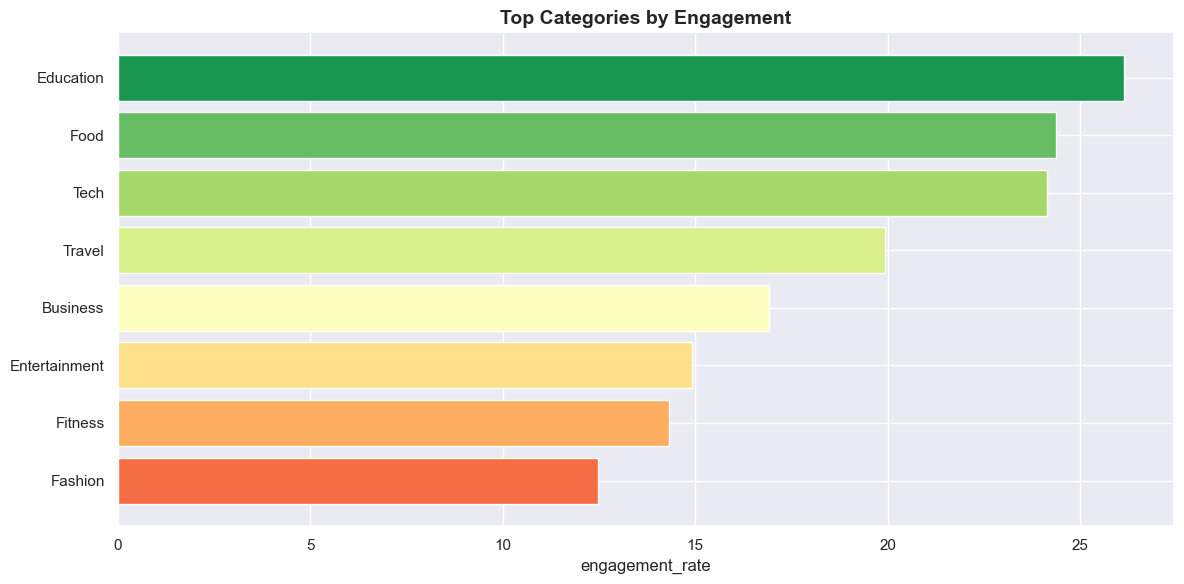


  FINAL REPORT SNAPSHOT
  Best Platform                  TikTok
  Best Content                   Image
  Best Day                       Monday
  Best Category                  Education
  Avg Engagement                 19.1260%
  Total Posts                    2,000


In [13]:
# CELL 12: Using reusable helpers from src/
import sys
sys.path.append('../src')
from analysis_helpers import (
    descriptive_stats, group_stats,
    correlation_summary, plot_top_n, print_summary, top_n_values
)

# Descriptive stats
descriptive_stats(df, ['likes', 'comments', 'shares', 'views', 'engagement_rate'])

# Group stats
group_stats(df, 'platform', 'engagement_rate')

# Correlation summary
correlation_summary(df, 'engagement_rate')

# Top categories chart
plot_top_n(df, 'category', 'engagement_rate', n=8,
           title='Top Categories by Engagement',
           save_as='08_top_categories.png')

# Summary print
print_summary("FINAL REPORT SNAPSHOT", {
    "Best Platform":   df.groupby('platform')['engagement_rate'].mean().idxmax(),
    "Best Content":    df.groupby('content_type')['engagement_rate'].mean().idxmax(),
    "Best Day":        df.groupby('day_of_week')['engagement_rate'].mean().idxmax(),
    "Best Category":   df.groupby('category')['engagement_rate'].mean().idxmax(),
    "Avg Engagement":  f"{df['engagement_rate'].mean():.4f}%",
    "Total Posts":     f"{len(df):,}",
})